In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler

from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

import matplotlib.pyplot as plt

In [ ]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
data = df[['Pclass','Sex','Age','Fare','Embarked','Survived']]

data.head()

,Pclass,Sex,Age,Fare,Embarked,Survived
0,3,male,22.0,7.2500,S,0
1,1,female,38.0,71.2833,C,1
2,3,female,26.0,7.9250,S,1
3,1,female,35.0,53.1000,S,1
4,3,male,35.0,8.0500,S,0


In [ ]:
data['Age'].fillna(data['Age'].median(), inplace=True)

data['Embarked'].fillna(data['Embarked'].mode()[0], inplace=True)

/tmp/ipykernel_1928/238892224.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Age'].fillna(data['Age'].median(), inplace=True)
/tmp/ipykernel_1928/238892224.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Age'].fillna(data['Age'].median(), inplace=True)
/tmp/ipykernel_1928/238892224.py:3: FutureWarning: A value is trying to

In [ ]:
le = LabelEncoder()

data['Sex_Label'] = le.fit_transform(data['Sex'])

data[['Sex','Sex_Label']].head()

/tmp/ipykernel_1928/1169349800.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Sex_Label'] = le.fit_transform(data['Sex'])


,Sex,Sex_Label
0,male,1
1,female,0
2,female,0
3,female,0
4,male,1


In [ ]:
encoder = OneHotEncoder(sparse_output=False)

encoded = encoder.fit_transform(data[['Embarked']])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(['Embarked'])
)

encoded_df.head()

,Embarked_C,Embarked_Q,Embarked_S
0,0.0,0.0,1.0
1,1.0,0.0,0.0
2,0.0,0.0,1.0
3,0.0,0.0,1.0
4,0.0,0.0,1.0


In [ ]:
data = pd.concat([data, encoded_df], axis=1)

data.head()

,Pclass,Sex,Age,Fare,Embarked,Survived,Sex_Label,Embarked_C,Embarked_Q,Embarked_S
0,3,male,22.0,7.2500,S,0,1,0.0,0.0,1.0
1,1,female,38.0,71.2833,C,1,0,1.0,0.0,0.0
2,3,female,26.0,7.9250,S,1,0,0.0,0.0,1.0
3,1,female,35.0,53.1000,S,1,0,0.0,0.0,1.0
4,3,male,35.0,8.0500,S,0,1,0.0,0.0,1.0


In [ ]:
data['Priority'] = np.random.choice(
    ['Low','Medium','High'],
    len(data)
)

In [ ]:
oe = OrdinalEncoder(
    categories=[['Low','Medium','High']]
)

data['Priority_Encoded'] = oe.fit_transform(
    data[['Priority']]
)

data[['Priority','Priority_Encoded']].head()

,Priority,Priority_Encoded
0,High,2.0
1,Low,0.0
2,Low,0.0
3,High,2.0
4,Low,0.0


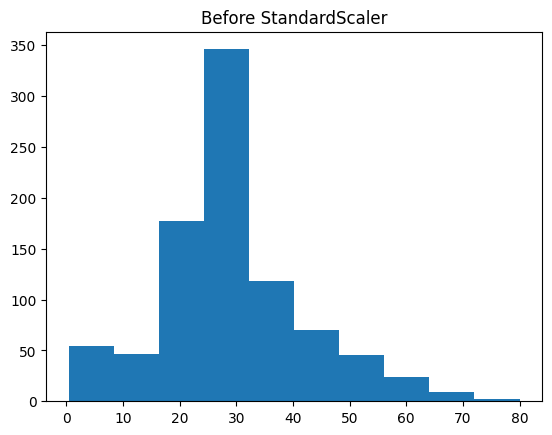

In [ ]:
plt.hist(data['Age'])
plt.title("Before StandardScaler")
plt.show()

In [ ]:
standard = StandardScaler()

data['Age_Standard'] = standard.fit_transform(
    data[['Age']]
)

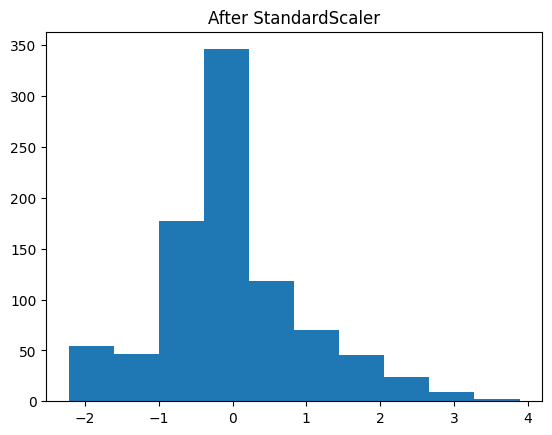

In [ ]:
plt.hist(data['Age_Standard'])
plt.title("After StandardScaler")
plt.show()

In [ ]:
minmax = MinMaxScaler()

data['Age_MinMax'] = minmax.fit_transform(
    data[['Age']]
)

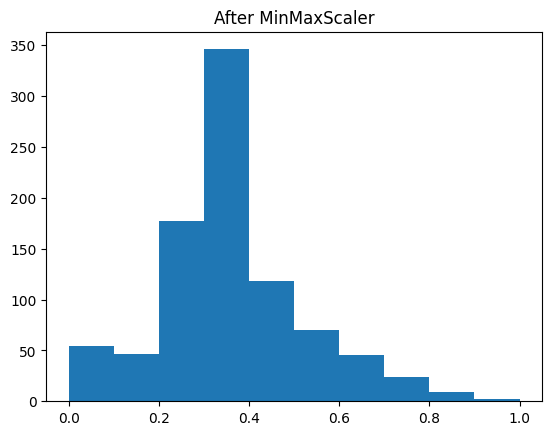

In [ ]:
plt.hist(data['Age_MinMax'])
plt.title("After MinMaxScaler")
plt.show()

In [ ]:
robust = RobustScaler()

data['Age_Robust'] = robust.fit_transform(
    data[['Age']]
)

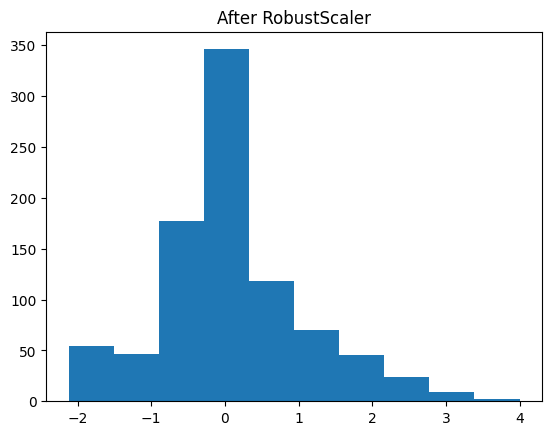

In [ ]:
plt.hist(data['Age_Robust'])
plt.title("After RobustScaler")
plt.show()

In [ ]:
data['Sex'] = LabelEncoder().fit_transform(data['Sex'])

data['Embarked'] = LabelEncoder().fit_transform(data['Embarked'])

In [ ]:
X = data[['Pclass',
          'Sex',
          'Age',
          'Fare',
          'Embarked']]

y = data['Survived']

In [ ]:
selector = SelectKBest(
    score_func=f_classif,
    k=5
)

X_new = selector.fit_transform(X,y)

In [ ]:
scores = pd.DataFrame({
    'Feature':X.columns,
    'Score':selector.scores_
})

scores = scores.sort_values(
    by='Score',
    ascending=False
)

print(scores)

    Feature       Score
1       Sex  372.405724
0    Pclass  115.031272
3      Fare   63.030764
4  Embarked   25.717286
2       Age    3.761528
